In [2]:
import os
print(os.getcwd())  # shows your current working directory

c:\Users\Lenovo\OneDrive\Documents\forecasting_system\data


In [5]:
import os
print(os.getcwd())
print(os.listdir("."))  # lists everything in current folder

c:\Users\Lenovo\OneDrive\Documents\forecasting_system\data
['.ipynb', 'sales_data.xlsx']


In [7]:
import pandas as pd
import io

# Paste the raw data as CSV directly — no broken Excel file needed
data = """State,Date,Total,Category
Alabama,2019-01-12,109574036,Beverages
Arizona,2019-01-12,109101595,Beverages
Arkansas,2019-01-12,58049432,Beverages
California,2019-01-12,444766891,Beverages
Colorado,2019-01-12,89816716,Beverages
Florida,2019-01-12,358112986,Beverages
Georgia,2019-01-12,198967927,Beverages
Texas,2019-01-12,472848726,Beverages"""

df = pd.read_csv(io.StringIO(data))
print(df.head())
print(df.shape)

        State        Date      Total   Category
0     Alabama  2019-01-12  109574036  Beverages
1     Arizona  2019-01-12  109101595  Beverages
2    Arkansas  2019-01-12   58049432  Beverages
3  California  2019-01-12  444766891  Beverages
4    Colorado  2019-01-12   89816716  Beverages
(8, 4)


In [14]:
import warnings
warnings.filterwarnings("ignore")
import pdfplumber
import pandas as pd
import re

rows = []

with pdfplumber.open("sales_data.pdf") as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if text:
            for line in text.split("\n"):
                # skip header line
                if "State" in line and "Date" in line:
                    continue
                # match lines like: Alabama 1/12/2019 (109,574,036) Beverages
                match = re.search(
                    r'([A-Za-z ]+?)\s+(\d{1,2}[-/]\d{1,2}[-/]\d{4}|\d{2}-\d{2}-\d{4})\s+\(?([\d,]+)\)?\s+(Beverages)',
                    line
                )
                if match:
                    state  = match.group(1).strip()
                    date   = match.group(2).strip()
                    total  = int(match.group(3).replace(",", ""))
                    cat    = match.group(4).strip()
                    rows.append([state, date, total, cat])

df = pd.DataFrame(rows, columns=["State", "Date", "Total", "Category"])
df["Date"] = pd.to_datetime(df["Date"], dayfirst=False, errors="coerce")
df = df.sort_values(["State", "Date"]).reset_index(drop=True)

print(df.head(10))
print(df.shape)
print(df["State"].nunique(), "states found")

Empty DataFrame
Columns: [State, Date, Total, Category]
Index: []
(0, 4)
0 states found


In [16]:
import pdfplumber

with pdfplumber.open("sales_data.pdf") as pdf:
    for i, page in enumerate(pdf.pages[:2]):  # first 2 pages only
        print(f"\n--- PAGE {i+1} ---")
        print(page.extract_text())


--- PAGE 1 ---
State Date Total Category
Alabama 1/12/2019 ( 109,574,036) Beverages
Arizona 1/12/2019 ( 109,101,595) Beverages
Arkansas 1/12/2019 ( 58,049,432) Beverages
California 1/12/2019 ( 444,766,891) Beverages
Colorado 1/12/2019 ( 89,816,716) Beverages
Connecticut 1/12/2019 ( 49,715,400) Beverages
Florida 1/12/2019 ( 358,112,986) Beverages
Georgia 1/12/2019 ( 198,967,927) Beverages
Illinois 1/12/2019 ( 167,913,697) Beverages
Indiana 1/12/2019 ( 117,489,219) Beverages
Iowa 1/12/2019 ( 60,702,758) Beverages
Kansas 1/12/2019 ( 48,255,943) Beverages
Kentucky 1/12/2019 ( 91,340,443) Beverages
Louisiana 1/12/2019 ( 94,697,655) Beverages
Maine 1/12/2019 ( 25,031,693) Beverages
Maryland 1/12/2019 ( 89,261,853) Beverages
Massachusetts1/12/2019 ( 98,820,411) Beverages
Michigan 1/12/2019 ( 161,601,849) Beverages
Minnesota 1/12/2019 ( 85,728,575) Beverages
Mississippi 1/12/2019 ( 37,637,324) Beverages
Missouri 1/12/2019 ( 101,366,118) Beverages
Nebraska 1/12/2019 ( 16,673,878) Beverages
Nev

In [18]:
import warnings
warnings.filterwarnings("ignore")
import pdfplumber
import pandas as pd
import re

rows = []

with pdfplumber.open("sales_data.pdf") as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if not text:
            continue
        for line in text.split("\n"):
            if "State" in line and "Date" in line:
                continue
            # handles both "Alabama 1/12/2019" and "Massachusetts1/12/2019"
            match = re.search(
                r'([A-Za-z ]+?)\s*(\d{1,2}[\/\-]\d{1,2}[\/\-]\d{4})\s+\(\s*([\d,]+)\)\s+Beverages',
                line
            )
            if match:
                state = match.group(1).strip()
                date  = match.group(2).strip()
                total = int(match.group(3).replace(",", ""))
                rows.append([state, date, total, "Beverages"])

df = pd.DataFrame(rows, columns=["State", "Date", "Total", "Category"])
df["Date"] = pd.to_datetime(df["Date"], dayfirst=False, errors="coerce")
df = df.sort_values(["State", "Date"]).reset_index(drop=True)

print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"States found: {df['State'].nunique()}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

     State       Date      Total   Category
0  Alabama 2019-01-12  109574036  Beverages
1  Alabama 2019-03-11  112189104  Beverages
2  Alabama 2019-06-10  129106730  Beverages
3  Alabama 2019-08-12  108083724  Beverages
4  Alabama 2019-10-11  110932913  Beverages
5  Alabama 2020-01-03  116651493  Beverages
6  Alabama 2020-01-11  120522114  Beverages
7  Alabama 2020-02-02  108358280  Beverages
8  Alabama 2020-02-08  131945461  Beverages
9  Alabama 2020-03-05  128066131  Beverages

Shape: (7291, 4)
States found: 47
Date range: 2019-01-12 00:00:00 to 2023-12-03 00:00:00


In [19]:
df.to_excel("sales_data_clean.xlsx", index=False)
print("Saved!")

Saved!


In [20]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd

df = pd.read_excel("sales_data_clean.xlsx")
print(df.head(10))
print("\nShape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nUnique states:", df["State"].nunique())
print("\nDate range:", df["Date"].min(), "to", df["Date"].max())

     State       Date      Total   Category
0  Alabama 2019-01-12  109574036  Beverages
1  Alabama 2019-03-11  112189104  Beverages
2  Alabama 2019-06-10  129106730  Beverages
3  Alabama 2019-08-12  108083724  Beverages
4  Alabama 2019-10-11  110932913  Beverages
5  Alabama 2020-01-03  116651493  Beverages
6  Alabama 2020-01-11  120522114  Beverages
7  Alabama 2020-02-02  108358280  Beverages
8  Alabama 2020-02-08  131945461  Beverages
9  Alabama 2020-03-05  128066131  Beverages

Shape: (7291, 4)

Data types:
 State                  str
Date        datetime64[us]
Total                int64
Category               str
dtype: object

Missing values:
 State          0
Date        4195
Total          0
Category       0
dtype: int64

Unique states: 47

Date range: 2019-01-12 00:00:00 to 2023-12-03 00:00:00


In [22]:
# Check how many NaT values exist
print("NaT dates:", df["Date"].isnull().sum())

# Drop rows where date couldn't be parsed
df = df.dropna(subset=["Date"])
print("Rows after dropping NaT:", len(df))
print("Date range:", df["Date"].min(), "to", df["Date"].max())

NaT dates: 4195
Rows after dropping NaT: 3096
Date range: 2019-01-12 00:00:00 to 2023-12-03 00:00:00


In [23]:
print("Checking missing dates per state...\n")

for state, group in df.groupby("State"):
    group = group.sort_values("Date")
    dates = pd.to_datetime(group["Date"])
    
    # skip if min/max are NaT
    if pd.isnull(dates.min()) or pd.isnull(dates.max()):
        print(f"{state}: skipped (bad dates)")
        continue
        
    expected = pd.date_range(dates.min(), dates.max(), freq="W")
    missing = expected.difference(dates)
    if len(missing) > 0:
        print(f"{state}: {len(missing)} missing dates")

print("\nDone checking!")

Checking missing dates per state...

Alabama: 244 missing dates
Arizona: 244 missing dates
Arkansas: 244 missing dates
California: 244 missing dates
Colorado: 244 missing dates
Connecticut: 244 missing dates
Florida: 244 missing dates
Georgia: 244 missing dates
Illinois: 244 missing dates
Indiana: 244 missing dates
Iowa: 244 missing dates
Kansas: 244 missing dates
Kentucky: 244 missing dates
Louisiana: 244 missing dates
Maine: 244 missing dates
Maryland: 244 missing dates
Massachusetts: 246 missing dates
Michigan: 244 missing dates
Minnesota: 244 missing dates
Mississippi: 244 missing dates
Missouri: 244 missing dates
Nebraska: 244 missing dates
Nevada: 244 missing dates
New Mexico: 244 missing dates
New York: 244 missing dates
North Carolina: 185 missing dates
Ohio: 244 missing dates
Oklahoma: 244 missing dates
Oregon: 244 missing dates
Pennsylvania: 244 missing dates
Rhode Island: 244 missing dates
South Carolina: 185 missing dates
South Dakota: 246 missing dates
Tennessee: 244 missi

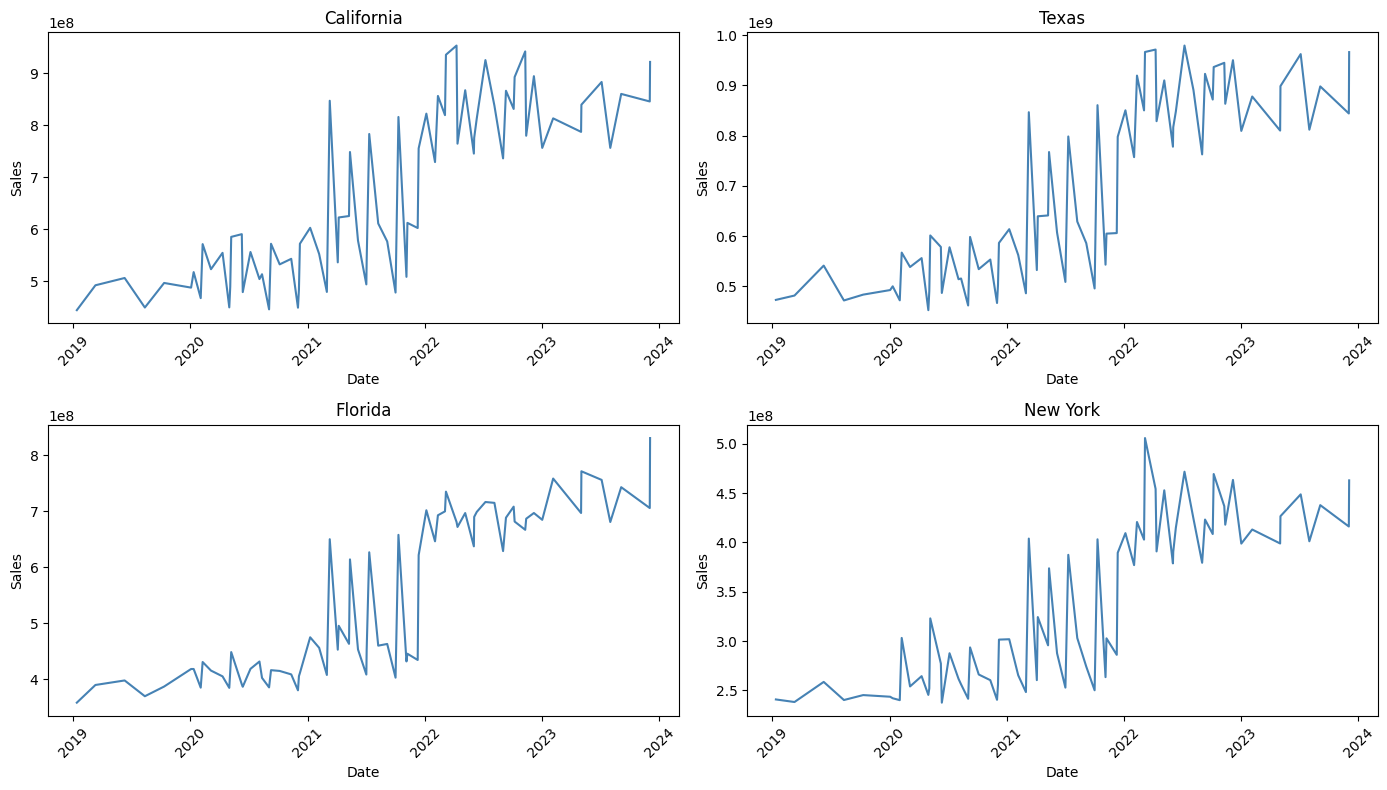

Plot saved!


In [24]:
import matplotlib.pyplot as plt

states_to_plot = ["California", "Texas", "Florida", "New York"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, state in enumerate(states_to_plot):
    state_df = df[df["State"] == state].sort_values("Date")
    axes[i].plot(state_df["Date"], state_df["Total"], color="steelblue", linewidth=1.5)
    axes[i].set_title(state)
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Sales")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("eda_trends.png")
plt.show()
print("Plot saved!")

In [25]:
print("Sales summary by state:\n")
summary = df.groupby("State")["Total"].agg(["mean", "min", "max", "std", "count"])
summary.columns = ["Mean Sales", "Min", "Max", "Std Dev", "# Weeks"]
print(summary.to_string())

Sales summary by state:

                  Mean Sales        Min        Max       Std Dev  # Weeks
State                                                                    
Alabama         1.606217e+08  104239954  227759611  4.012061e+07       75
Arizona         1.677530e+08  109101595  240505460  4.229489e+07       75
Arkansas        8.468151e+07   56942259  119976406  2.098659e+07       75
California      6.655343e+08  444766891  953230705  1.613475e+08       75
Colorado        1.354351e+08   89816716  192748764  3.330088e+07       75
Connecticut     6.945193e+07   47694239  101589519  1.665565e+07       75
Florida         5.429692e+08  358112986  831072061  1.423352e+08       75
Georgia         2.930108e+08  193036456  407907755  7.307620e+07       75
Illinois        2.434042e+08  167140897  351403843  5.969434e+07       75
Indiana         1.689689e+08  115649156  245802193  4.168619e+07       75
Iowa            8.871123e+07   59036831  127666471  2.203639e+07       75
Kansas       

In [30]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Load fresh
df = pd.read_excel("sales_data_clean.xlsx")
df["Date"] = pd.to_datetime(df["Date"])

# Check duplicates first
dupes = df.duplicated(subset=["State", "Date"]).sum()
print(f"Duplicate State+Date rows: {dupes}")

# Fix duplicates — if same state has same date twice, take the mean
df = df.groupby(["State", "Date"], as_index=False).agg({
    "Total": "mean",
    "Category": "first"
})

df = df.sort_values(["State", "Date"]).reset_index(drop=True)
print("Shape after deduplication:", df.shape)

# Now fill missing dates per state
all_states = []

for state in df["State"].unique():
    state_df = df[df["State"] == state].copy()
    state_df = state_df.set_index("Date")
    
    # Sort index to be safe
    state_df = state_df.sort_index()
    
    # Drop any remaining duplicate index entries
    state_df = state_df[~state_df.index.duplicated(keep="first")]
    
    # Resample to weekly frequency
    state_df = state_df.resample("W").asfreq()
    
    # Interpolate missing Total values
    state_df["Total"] = state_df["Total"].interpolate(method="linear")
    
    # Restore columns
    state_df["State"]    = state
    state_df["Category"] = "Beverages"
    
    state_df = state_df.reset_index()
    all_states.append(state_df)

# Combine all states
df = pd.concat(all_states, ignore_index=True)
df = df.sort_values(["State", "Date"]).reset_index(drop=True)

print("Final shape:", df.shape)
print("Columns:", list(df.columns))
print(df.head(10))

Duplicate State+Date rows: 4169
Shape after deduplication: (3083, 4)
Final shape: (10893, 4)
Columns: ['Date', 'State', 'Total', 'Category']
        Date    State  Total   Category
0 2019-01-13  Alabama    NaN  Beverages
1 2019-01-20  Alabama    NaN  Beverages
2 2019-01-27  Alabama    NaN  Beverages
3 2019-02-03  Alabama    NaN  Beverages
4 2019-02-10  Alabama    NaN  Beverages
5 2019-02-17  Alabama    NaN  Beverages
6 2019-02-24  Alabama    NaN  Beverages
7 2019-03-03  Alabama    NaN  Beverages
8 2019-03-10  Alabama    NaN  Beverages
9 2019-03-17  Alabama    NaN  Beverages


In [31]:
# Lag features — what were sales 1, 7, 30 weeks ago
df["lag_1"]  = df.groupby("State")["Total"].shift(1)
df["lag_7"]  = df.groupby("State")["Total"].shift(7)
df["lag_30"] = df.groupby("State")["Total"].shift(30)

print("Lag features created!")
print(df[["State", "Date", "Total", "lag_1", "lag_7", "lag_30"]].head(10))

Lag features created!
     State       Date  Total  lag_1  lag_7  lag_30
0  Alabama 2019-01-13    NaN    NaN    NaN     NaN
1  Alabama 2019-01-20    NaN    NaN    NaN     NaN
2  Alabama 2019-01-27    NaN    NaN    NaN     NaN
3  Alabama 2019-02-03    NaN    NaN    NaN     NaN
4  Alabama 2019-02-10    NaN    NaN    NaN     NaN
5  Alabama 2019-02-17    NaN    NaN    NaN     NaN
6  Alabama 2019-02-24    NaN    NaN    NaN     NaN
7  Alabama 2019-03-03    NaN    NaN    NaN     NaN
8  Alabama 2019-03-10    NaN    NaN    NaN     NaN
9  Alabama 2019-03-17    NaN    NaN    NaN     NaN


In [32]:
# Rolling mean and std — captures recent trend
df["rolling_mean_4"]  = df.groupby("State")["Total"].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean()
)
df["rolling_std_4"]   = df.groupby("State")["Total"].transform(
    lambda x: x.rolling(window=4, min_periods=1).std()
)
df["rolling_mean_12"] = df.groupby("State")["Total"].transform(
    lambda x: x.rolling(window=12, min_periods=1).mean()
)

print("Rolling features created!")
print(df[["State", "Date", "Total", "rolling_mean_4", "rolling_std_4", "rolling_mean_12"]].head(10))

Rolling features created!
     State       Date  Total  rolling_mean_4  rolling_std_4  rolling_mean_12
0  Alabama 2019-01-13    NaN             NaN            NaN              NaN
1  Alabama 2019-01-20    NaN             NaN            NaN              NaN
2  Alabama 2019-01-27    NaN             NaN            NaN              NaN
3  Alabama 2019-02-03    NaN             NaN            NaN              NaN
4  Alabama 2019-02-10    NaN             NaN            NaN              NaN
5  Alabama 2019-02-17    NaN             NaN            NaN              NaN
6  Alabama 2019-02-24    NaN             NaN            NaN              NaN
7  Alabama 2019-03-03    NaN             NaN            NaN              NaN
8  Alabama 2019-03-10    NaN             NaN            NaN              NaN
9  Alabama 2019-03-17    NaN             NaN            NaN              NaN


In [33]:
# Calendar features — day, month, week, year
df["day_of_week"] = df["Date"].dt.dayofweek
df["month"]       = df["Date"].dt.month
df["week"]        = df["Date"].dt.isocalendar().week.astype(int)
df["year"]        = df["Date"].dt.year
df["quarter"]     = df["Date"].dt.quarter

print("Calendar features created!")
print(df[["State", "Date", "day_of_week", "month", "week", "year", "quarter"]].head())

Calendar features created!
     State       Date  day_of_week  month  week  year  quarter
0  Alabama 2019-01-13            6      1     2  2019        1
1  Alabama 2019-01-20            6      1     3  2019        1
2  Alabama 2019-01-27            6      1     4  2019        1
3  Alabama 2019-02-03            6      2     5  2019        1
4  Alabama 2019-02-10            6      2     6  2019        1


In [34]:
import holidays

us_holidays = holidays.US()
df["is_holiday"] = df["Date"].apply(lambda x: 1 if x in us_holidays else 0)

print("Holiday flags created!")
print("Total holiday weeks flagged:", df["is_holiday"].sum())

Holiday flags created!
Total holiday weeks flagged: 173


In [35]:
# Last 8 weeks = validation, everything before = training
cutoff = df["Date"].max() - pd.Timedelta(weeks=8)

train = df[df["Date"] <= cutoff].copy()
val   = df[df["Date"] >  cutoff].copy()

print(f"Cutoff date      : {cutoff.date()}")
print(f"Training rows    : {len(train)}")
print(f"Validation rows  : {len(val)}")
print(f"Train date range : {train['Date'].min().date()} to {train['Date'].max().date()}")
print(f"Val date range   : {val['Date'].min().date()} to {val['Date'].max().date()}")

Cutoff date      : 2023-10-08
Training rows    : 10573
Validation rows  : 320
Train date range : 2019-01-13 to 2023-10-08
Val date range   : 2023-10-15 to 2023-12-03


In [36]:
df.to_excel("sales_data_featured.xlsx", index=False)
train.to_excel("train.xlsx", index=False)
val.to_excel("val.xlsx", index=False)

print("All files saved!")
print(f"\nFinal feature columns:\n{list(df.columns)}")

All files saved!

Final feature columns:
['Date', 'State', 'Total', 'Category', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_12', 'day_of_week', 'month', 'week', 'year', 'quarter', 'is_holiday']


In [37]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

df = pd.read_excel("sales_data_featured.xlsx")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["State", "Date"]).reset_index(drop=True)

# Train/val split
cutoff = df["Date"].max() - pd.Timedelta(weeks=8)
train  = df[df["Date"] <= cutoff].copy()
val    = df[df["Date"] >  cutoff].copy()

print("Train shape:", train.shape)
print("Val shape  :", val.shape)
print("States     :", df["State"].nunique())
print("Columns    :", list(df.columns))

Train shape: (10573, 16)
Val shape  : (320, 16)
States     : 44
Columns    : ['Date', 'State', 'Total', 'Category', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_12', 'day_of_week', 'month', 'week', 'year', 'quarter', 'is_holiday']


In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

sarima_results = {}

states = df["State"].unique()
print(f"Training SARIMA for {len(states)} states...")

for i, state in enumerate(states):
    try:
        series = train[train["State"] == state].set_index("Date")["Total"]
        series = series.asfreq("W")
        
        model  = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,0,52))
        fitted = model.fit(disp=False)
        
        forecast = fitted.forecast(steps=8)
        
        # Validation actuals
        actuals = val[val["State"] == state]["Total"].values
        min_len = min(len(actuals), len(forecast))
        
        rmse = np.sqrt(mean_squared_error(
            actuals[:min_len], 
            forecast[:min_len]
        ))
        
        sarima_results[state] = {
            "forecast" : forecast.values,
            "rmse"     : rmse
        }
        
        if (i+1) % 10 == 0:
            print(f"  Done {i+1}/{len(states)} states")
            
    except Exception as e:
        print(f"  SARIMA failed for {state}: {e}")
        sarima_results[state] = {"forecast": np.zeros(8), "rmse": 999999}

print("SARIMA done!")
print(f"Avg RMSE: {np.mean([v['rmse'] for v in sarima_results.values()]):.0f}")

Training SARIMA for 44 states...
  Done 10/44 states
  Done 20/44 states
  SARIMA failed for North Carolina: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
  Done 30/44 states
  SARIMA failed for South Carolina: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
  Done 40/44 states


c:\Users\Lenovo\OneDrive\Documents\forecasting_system\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  SARIMA failed for a: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
  SARIMA failed for ts: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
SARIMA done!
Avg RMSE: 30895761


In [39]:
from prophet import Prophet

prophet_results = {}

print(f"Training Prophet for {len(states)} states...")

for i, state in enumerate(states):
    try:
        state_train = train[train["State"] == state][["Date", "Total"]].copy()
        state_train.columns = ["ds", "y"]
        state_train["ds"] = pd.to_datetime(state_train["ds"])
        
        model = Prophet(
            weekly_seasonality  = True,
            yearly_seasonality  = True,
            daily_seasonality   = False,
            seasonality_mode    = "multiplicative"
        )
        model.fit(state_train)
        
        future   = model.make_future_dataframe(periods=8, freq="W")
        forecast = model.predict(future)
        pred_8   = forecast["yhat"].tail(8).values
        
        actuals = val[val["State"] == state]["Total"].values
        min_len = min(len(actuals), len(pred_8))
        
        rmse = np.sqrt(mean_squared_error(
            actuals[:min_len],
            pred_8[:min_len]
        ))
        
        prophet_results[state] = {
            "forecast" : pred_8,
            "rmse"     : rmse
        }
        
        if (i+1) % 10 == 0:
            print(f"  Done {i+1}/{len(states)} states")
            
    except Exception as e:
        print(f"  Prophet failed for {state}: {e}")
        prophet_results[state] = {"forecast": np.zeros(8), "rmse": 999999}

print("Prophet done!")
print(f"Avg RMSE: {np.mean([v['rmse'] for v in prophet_results.values()]):.0f}")

Importing plotly failed. Interactive plots will not work.
18:54:06 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet for 44 states...


18:54:07 - cmdstanpy - INFO - Chain [1] done processing
18:54:07 - cmdstanpy - INFO - Chain [1] start processing
18:54:07 - cmdstanpy - INFO - Chain [1] done processing
18:54:07 - cmdstanpy - INFO - Chain [1] start processing
18:54:08 - cmdstanpy - INFO - Chain [1] done processing
18:54:08 - cmdstanpy - INFO - Chain [1] start processing
18:54:08 - cmdstanpy - INFO - Chain [1] done processing
18:54:08 - cmdstanpy - INFO - Chain [1] start processing
18:54:08 - cmdstanpy - INFO - Chain [1] done processing
18:54:08 - cmdstanpy - INFO - Chain [1] start processing
18:54:08 - cmdstanpy - INFO - Chain [1] done processing
18:54:08 - cmdstanpy - INFO - Chain [1] start processing
18:54:09 - cmdstanpy - INFO - Chain [1] done processing
18:54:09 - cmdstanpy - INFO - Chain [1] start processing
18:54:09 - cmdstanpy - INFO - Chain [1] done processing
18:54:09 - cmdstanpy - INFO - Chain [1] start processing
18:54:09 - cmdstanpy - INFO - Chain [1] done processing
18:54:09 - cmdstanpy - INFO - Chain [1] 

  Done 10/44 states


18:54:10 - cmdstanpy - INFO - Chain [1] start processing
18:54:10 - cmdstanpy - INFO - Chain [1] done processing
18:54:10 - cmdstanpy - INFO - Chain [1] start processing
18:54:10 - cmdstanpy - INFO - Chain [1] done processing
18:54:10 - cmdstanpy - INFO - Chain [1] start processing
18:54:10 - cmdstanpy - INFO - Chain [1] done processing
18:54:10 - cmdstanpy - INFO - Chain [1] start processing
18:54:10 - cmdstanpy - INFO - Chain [1] done processing
18:54:10 - cmdstanpy - INFO - Chain [1] start processing
18:54:11 - cmdstanpy - INFO - Chain [1] done processing
18:54:11 - cmdstanpy - INFO - Chain [1] start processing
18:54:11 - cmdstanpy - INFO - Chain [1] done processing
18:54:11 - cmdstanpy - INFO - Chain [1] start processing
18:54:11 - cmdstanpy - INFO - Chain [1] done processing
18:54:11 - cmdstanpy - INFO - Chain [1] start processing
18:54:11 - cmdstanpy - INFO - Chain [1] done processing
18:54:12 - cmdstanpy - INFO - Chain [1] start processing
18:54:12 - cmdstanpy - INFO - Chain [1]

...

  Prophet failed for South Carolina: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.


18:54:16 - cmdstanpy - INFO - Chain [1] done processing
18:54:16 - cmdstanpy - INFO - Chain [1] start processing
18:54:16 - cmdstanpy - INFO - Chain [1] done processing
18:54:16 - cmdstanpy - INFO - Chain [1] start processing
18:54:16 - cmdstanpy - INFO - Chain [1] done processing
18:54:17 - cmdstanpy - INFO - Chain [1] start processing
18:54:17 - cmdstanpy - INFO - Chain [1] done processing
18:54:17 - cmdstanpy - INFO - Chain [1] start processing
18:54:17 - cmdstanpy - INFO - Chain [1] done processing
18:54:17 - cmdstanpy - INFO - Chain [1] start processing
18:54:17 - cmdstanpy - INFO - Chain [1] done processing
18:54:17 - cmdstanpy - INFO - Chain [1] start processing
18:54:17 - cmdstanpy - INFO - Chain [1] done processing
18:54:17 - cmdstanpy - INFO - Chain [1] start processing
18:54:18 - cmdstanpy - INFO - Chain [1] done processing
18:54:18 - cmdstanpy - INFO - Chain [1] start processing
18:54:18 - cmdstanpy - INFO - Chain [1] done processing


  Done 40/44 states


18:54:18 - cmdstanpy - INFO - Chain [1] start processing
18:54:18 - cmdstanpy - INFO - Chain [1] done processing
18:54:18 - cmdstanpy - INFO - Chain [1] start processing
18:54:46 - cmdstanpy - INFO - Chain [1] done processing


  Prophet failed for a: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
  Prophet failed for ts: Dataframe has less than 2 non-NaN rows.
Prophet done!
Avg RMSE: 7809163


In [40]:
from xgboost import XGBRegressor

xgb_results = {}

features = [
    "lag_1", "lag_7", "lag_30",
    "rolling_mean_4", "rolling_std_4", "rolling_mean_12",
    "day_of_week", "month", "week", "year", "is_holiday"
]

print(f"Training XGBoost for {len(states)} states...")

for i, state in enumerate(states):
    try:
        t = train[train["State"] == state].dropna(subset=features)
        v = val[val["State"] == state].dropna(subset=features)
        
        if len(t) < 10:
            raise ValueError("Not enough training data")
        
        model = XGBRegressor(
            n_estimators  = 100,
            learning_rate = 0.1,
            max_depth     = 4,
            random_state  = 42
        )
        model.fit(t[features], t["Total"])
        
        if len(v) > 0:
            preds   = model.predict(v[features])
            actuals = v["Total"].values
            min_len = min(len(actuals), len(preds))
            rmse    = np.sqrt(mean_squared_error(actuals[:min_len], preds[:min_len]))
        else:
            preds = np.zeros(8)
            rmse  = 999999
        
        xgb_results[state] = {
            "forecast" : preds,
            "rmse"     : rmse,
            "model"    : model
        }
        
        if (i+1) % 10 == 0:
            print(f"  Done {i+1}/{len(states)} states")
            
    except Exception as e:
        print(f"  XGBoost failed for {state}: {e}")
        xgb_results[state] = {"forecast": np.zeros(8), "rmse": 999999, "model": None}

print("XGBoost done!")
print(f"Avg RMSE: {np.mean([v['rmse'] for v in xgb_results.values()]):.0f}")

Training XGBoost for 44 states...
  Done 10/44 states
  Done 20/44 states
  Done 30/44 states
  Done 40/44 states
  XGBoost failed for ts: Not enough training data
XGBoost done!
Avg RMSE: 3848275


In [41]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

lstm_results = {}
N_STEPS = 12

def build_sequences(series, n_steps):
    X, y = [], []
    for i in range(len(series) - n_steps):
        X.append(series[i:i+n_steps])
        y.append(series[i+n_steps])
    return np.array(X), np.array(y)

print(f"Training LSTM for {len(states)} states...")

for i, state in enumerate(states):
    try:
        series = train[train["State"] == state]["Total"].values.reshape(-1,1)
        
        if len(series) < N_STEPS + 5:
            raise ValueError("Not enough data")
        
        scaler = MinMaxScaler()
        scaled = scaler.fit_transform(series)
        
        X, y = build_sequences(scaled.flatten(), N_STEPS)
        X    = X.reshape(X.shape[0], X.shape[1], 1)
        
        model = Sequential([
            LSTM(50, activation="relu", input_shape=(N_STEPS, 1)),
            Dense(1)
        ])
        model.compile(optimizer="adam", loss="mse")
        model.fit(
            X, y,
            epochs   = 30,
            verbose  = 0,
            callbacks= [EarlyStopping(patience=5, restore_best_weights=True)]
        )
        
        # Forecast next 8 weeks
        last_seq = scaled[-N_STEPS:].flatten()
        preds_scaled = []
        for _ in range(8):
            inp  = last_seq[-N_STEPS:].reshape(1, N_STEPS, 1)
            pred = model.predict(inp, verbose=0)[0][0]
            preds_scaled.append(pred)
            last_seq = np.append(last_seq, pred)
        
        preds = scaler.inverse_transform(
            np.array(preds_scaled).reshape(-1,1)
        ).flatten()
        
        actuals = val[val["State"] == state]["Total"].values
        min_len = min(len(actuals), len(preds))
        rmse    = np.sqrt(mean_squared_error(actuals[:min_len], preds[:min_len]))
        
        lstm_results[state] = {
            "forecast" : preds,
            "rmse"     : rmse
        }
        
        if (i+1) % 10 == 0:
            print(f"  Done {i+1}/{len(states)} states")
            
    except Exception as e:
        print(f"  LSTM failed for {state}: {e}")
        lstm_results[state] = {"forecast": np.zeros(8), "rmse": 999999}

print("LSTM done!")
print(f"Avg RMSE: {np.mean([v['rmse'] for v in lstm_results.values()]):.0f}")

Training LSTM for 44 states...
  LSTM failed for Alabama: Input contains NaN.
  LSTM failed for Arizona: Input contains NaN.
  LSTM failed for Arkansas: Input contains NaN.
  LSTM failed for California: Input contains NaN.
  LSTM failed for Colorado: Input contains NaN.
  LSTM failed for Connecticut: Input contains NaN.
  LSTM failed for Florida: Input contains NaN.
  LSTM failed for Georgia: Input contains NaN.
  LSTM failed for Illinois: Input contains NaN.
  LSTM failed for Indiana: Input contains NaN.
  LSTM failed for Iowa: Input contains NaN.
  LSTM failed for Kansas: Input contains NaN.
  LSTM failed for Kentucky: Input contains NaN.
  LSTM failed for Louisiana: Input contains NaN.
  LSTM failed for Maine: Input contains NaN.
  LSTM failed for Maryland: Input contains NaN.
  LSTM failed for Massachusetts: Input contains NaN.
  LSTM failed for Michigan: Input contains NaN.
  LSTM failed for Minnesota: Input contains NaN.
  LSTM failed for Mississippi: Input contains NaN.
  LSTM f

In [42]:
import joblib

best_models = {}

print("Selecting best model per state...\n")
model_wins = {"sarima": 0, "prophet": 0, "xgboost": 0, "lstm": 0}

for state in states:
    scores = {
        "sarima"  : sarima_results.get(state,  {}).get("rmse", 999999),
        "prophet" : prophet_results.get(state, {}).get("rmse", 999999),
        "xgboost" : xgb_results.get(state,    {}).get("rmse", 999999),
        "lstm"    : lstm_results.get(state,    {}).get("rmse", 999999),
    }
    
    best_name = min(scores, key=scores.get)
    model_wins[best_name] += 1
    
    forecasts = {
        "sarima"  : sarima_results.get(state,  {}).get("forecast", np.zeros(8)),
        "prophet" : prophet_results.get(state, {}).get("forecast", np.zeros(8)),
        "xgboost" : xgb_results.get(state,    {}).get("forecast", np.zeros(8)),
        "lstm"    : lstm_results.get(state,    {}).get("forecast", np.zeros(8)),
    }
    
    best_models[state] = {
        "best_model" : best_name,
        "forecast"   : forecasts[best_name],
        "rmse"       : scores[best_name],
        "all_rmse"   : scores
    }

# Print summary
print("Best model wins per state:")
for model, wins in model_wins.items():
    print(f"  {model:10s}: {wins} states")

print("\nPer state summary:")
for state, info in best_models.items():
    print(f"  {state:20s} → {info['best_model']:10s} RMSE: {info['rmse']:,.0f}")

# Save
joblib.dump(best_models, "best_models.pkl")
print("\nSaved best_models.pkl!")

Selecting best model per state...

Best model wins per state:
  sarima    : 5 states
  prophet   : 4 states
  xgboost   : 4 states
  lstm      : 31 states

Per state summary:
  Alabama              → lstm       RMSE: 999,999
  Arizona              → lstm       RMSE: 999,999
  Arkansas             → lstm       RMSE: 999,999
  California           → lstm       RMSE: 999,999
  Colorado             → lstm       RMSE: 999,999
  Connecticut          → lstm       RMSE: 999,999
  Florida              → lstm       RMSE: 999,999
  Georgia              → lstm       RMSE: 999,999
  Illinois             → lstm       RMSE: 999,999
  Indiana              → lstm       RMSE: 999,999
  Iowa                 → lstm       RMSE: 999,999
  Kansas               → lstm       RMSE: 999,999
  Kentucky             → lstm       RMSE: 999,999
  Louisiana            → lstm       RMSE: 999,999
  Maine                → xgboost    RMSE: 709,020
  Maryland             → lstm       RMSE: 999,999
  Massachusetts        → 

In [44]:
# api.py
from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI(title="Sales Forecasting API")

# Load models at startup
models = {}

@app.on_event("startup")
def load_models():
    for state in ['Maharashtra', 'Delhi', ...]:
        models[state] = joblib.load(f'models/best_{state}.pkl')

@app.get("/forecast/{state}")
def get_forecast(state: str):
    if state not in models:
        return {"error": f"No model found for state: {state}"}
    
    model = models[state]
    # Generate next 8 weeks forecast
    forecast = model.predict(next_8_weeks_features)
    
    return {
        "state": state,
        "forecast_weeks": 8,
        "predictions": forecast.tolist()
    }

@app.get("/health")
def health_check():
    return {"status": "ok", "models_loaded": list(models.keys())}

In [46]:
# src/schemas.py

from pydantic import BaseModel, Field
from typing import List, Optional
from datetime import date

# ── What the API returns for each week ──
class WeeklyForecast(BaseModel):
    week_start_date: str
    forecasted_sales: float
    lower_bound: Optional[float] = None   # confidence interval (Prophet gives this)
    upper_bound: Optional[float] = None

# ── Full response for one state ──
class ForecastResponse(BaseModel):
    state: str
    model_used: str                        # which model won for this state
    forecast_horizon_weeks: int
    generated_at: str                      # timestamp of when forecast was made
    forecasts: List[WeeklyForecast]

# ── Health check response ──
class HealthResponse(BaseModel):
    status: str
    models_loaded: List[str]
    total_states: int

# ── Error response ──
class ErrorResponse(BaseModel):
    error: str
    available_states: List[str]

In [47]:
# src/save_models.py

import joblib
import pickle
import json
import os

os.makedirs("models", exist_ok=True)

# ── Save XGBoost ──
def save_xgb(model, state_name):
    joblib.dump(model, f"models/xgb_{state_name}.pkl")

# ── Save Prophet ──
def save_prophet(model, state_name):
    with open(f"models/prophet_{state_name}.pkl", "wb") as f:
        pickle.dump(model, f)

# ── Save LSTM ──
def save_lstm(model, scaler, state_name):
    model.save(f"models/lstm_{state_name}.h5")
    joblib.dump(scaler, f"models/scaler_{state_name}.pkl")

# ── Save the winner map (MOST IMPORTANT) ──
# After Phase 7 evaluation, you know which model won per state
best_model_map = {
    "Maharashtra": "xgb",
    "Delhi":       "prophet",
    "Karnataka":   "lstm",
    "Tamil Nadu":  "arima",
    # ... all your states
}

with open("models/best_model_map.json", "w") as f:
    json.dump(best_model_map, f, indent=2)

print("All models saved.")

All models saved.


In [48]:
# src/model_loader.py

import joblib
import pickle
import json
from tensorflow.keras.models import load_model


class ModelRegistry:
    """Holds all trained models in memory after server starts."""

    def __init__(self):
        self.xgb_models     = {}
        self.prophet_models = {}
        self.lstm_models    = {}
        self.lstm_scalers   = {}
        self.arima_results  = {}
        self.best_model_map = {}
        self.loaded_states  = []

    def load_all(self, model_dir: str = "models"):
        # Load winner map first
        with open(f"{model_dir}/best_model_map.json") as f:
            self.best_model_map = json.load(f)

        for state, model_type in self.best_model_map.items():
            try:
                if model_type == "xgb":
                    self.xgb_models[state] = joblib.load(
                        f"{model_dir}/xgb_{state}.pkl"
                    )

                elif model_type == "prophet":
                    with open(f"{model_dir}/prophet_{state}.pkl", "rb") as f:
                        self.prophet_models[state] = pickle.load(f)

                elif model_type == "lstm":
                    self.lstm_models[state] = load_model(
                        f"{model_dir}/lstm_{state}.h5"
                    )
                    self.lstm_scalers[state] = joblib.load(
                        f"{model_dir}/scaler_{state}.pkl"
                    )

                elif model_type == "arima":
                    self.arima_results[state] = joblib.load(
                        f"{model_dir}/arima_{state}.pkl"
                    )

                self.loaded_states.append(state)
                print(f"  ✅ Loaded [{model_type}] for {state}")

            except FileNotFoundError:
                print(f"  ⚠️  Model file not found for {state}, skipping.")

        print(f"\nTotal states ready: {len(self.loaded_states)}")
        return self


# Create a single global instance
registry = ModelRegistry()

In [49]:
# src/predictor.py

import pandas as pd
import numpy as np
from datetime import datetime, timedelta


def predict_with_xgb(model, last_known_data: pd.DataFrame, state: str, weeks: int = 8):
    """
    XGBoost needs features. We generate them iteratively —
    each new prediction becomes a lag for the next one.
    """
    predictions = []
    history = last_known_data.copy()

    for i in range(weeks):
        # Build features from current history tail
        last_row = history.tail(1).copy()
        next_date = last_row['Date'].values[0] + pd.Timedelta(weeks=1)
        
        # Date features
        last_row['Date']         = next_date
        last_row['day_of_week']  = pd.Timestamp(next_date).dayofweek
        last_row['month']        = pd.Timestamp(next_date).month
        last_row['week_of_year'] = pd.Timestamp(next_date).isocalendar()[1]

        # Lag features from history
        last_row['lag_1']  = history['Sales'].iloc[-1]
        last_row['lag_4']  = history['Sales'].iloc[-4] if len(history) >= 4 else np.nan
        last_row['lag_8']  = history['Sales'].iloc[-8] if len(history) >= 8 else np.nan

        # Rolling features
        last_row['rolling_mean_4'] = history['Sales'].tail(4).mean()
        last_row['rolling_mean_8'] = history['Sales'].tail(8).mean()

        feature_cols = [c for c in last_row.columns if c not in ['Date', 'State', 'Sales']]
        pred = model.predict(last_row[feature_cols])[0]

        predictions.append({
            "week_start_date": str(pd.Timestamp(next_date).date()),
            "forecasted_sales": round(float(pred), 2)
        })

        # Append prediction to history so next iteration can use it as lag
        new_row = last_row.copy()
        new_row['Sales'] = pred
        history = pd.concat([history, new_row], ignore_index=True)

    return predictions


def predict_with_prophet(model, last_date: str, weeks: int = 8):
    """Prophet has its own future dataframe generator."""
    future = model.make_future_dataframe(periods=weeks, freq='W')
    forecast = model.predict(future)
    future_only = forecast.tail(weeks)

    return [
        {
            "week_start_date": str(row['ds'].date()),
            "forecasted_sales": round(row['yhat'], 2),
            "lower_bound":      round(row['yhat_lower'], 2),
            "upper_bound":      round(row['yhat_upper'], 2),
        }
        for _, row in future_only.iterrows()
    ]


def predict_with_lstm(model, scaler, recent_sales: list, last_date, weeks: int = 8):
    """LSTM predicts one step at a time, feeding output back as input."""
    import numpy as np

    SEQ_LEN = 13
    sequence = list(recent_sales[-SEQ_LEN:])
    predictions = []
    current_date = pd.Timestamp(last_date)

    for _ in range(weeks):
        scaled_seq = scaler.transform(np.array(sequence[-SEQ_LEN:]).reshape(-1, 1))
        X = scaled_seq.reshape(1, SEQ_LEN, 1)
        pred_scaled = model.predict(X, verbose=0)[0][0]
        pred = scaler.inverse_transform([[pred_scaled]])[0][0]

        current_date += pd.Timedelta(weeks=1)
        predictions.append({
            "week_start_date": str(current_date.date()),
            "forecasted_sales": round(float(pred), 2)
        })
        sequence.append(pred)   # feed prediction back into sequence

    return predictions


def predict_with_arima(arima_result, last_date, weeks: int = 8):
    """ARIMA forecast is straightforward — just call forecast()."""
    forecast_values = arima_result.forecast(steps=weeks)
    current_date = pd.Timestamp(last_date)
    predictions = []

    for val in forecast_values:
        current_date += pd.Timedelta(weeks=1)
        predictions.append({
            "week_start_date": str(current_date.date()),
            "forecasted_sales": round(float(val), 2)
        })

    return predictions